# Lecture 2 — Julia and VFI

**Computational Methods for Heterogeneous-Agent Macro**  
Jeffrey Sun

Solve the consumption-savings problem with no income shocks by Value Function Iteration (VFI).

Steps:
1. Define $V$ as a vector on a finite wealth grid.
2. Define the Bellman operator taking $V \mapsto \mathcal{T}V$ as a function taking a vector to a vector.
3. Repeatedly apply $\mathcal{T}\mathcal{T}\cdots\mathcal{T}\mathcal{T}V$ until convergence.

**Note:** This code is not very optimized. I am using allocating functions, plain grid search, no Howard improvement, etc., etc.. I wrote it to be clear rather than fast. The fast versions are in $\texttt{HouseholdStages.jl}$.

### Environment


In [1]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
using Plots

  Activating project at `~/projects/research/CV is all you need`


# Core Code


### Utility and Log Grid

CRRA utility on `c > 0`, with the `γ = 1` case routed to `log`. A
log-spaced grid clusters points near the borrowing constraint.


In [2]:
u(c) = c <= 0 ? -Inf : log(c)
loggrid(lo, hi, N) = exp.(range(log(lo), log(hi); length=N))

loggrid (generic function with 1 method)

### Bellman Operator

Given a value function (guess) $V$, for each $b$ compute,
$$
TV(b) = \max_{b'} u(c) + \beta V(b'),
$$
where
$$
\begin{align*}
    c &= b - b^\text{end},\\
    b^\text{end} &= \frac{b' - z}{R},
\end{align*}
$$
and $z$ is the agent's productivity / human-capital.


In [3]:
"""
Apply Bellman operator V |-> TV, when V is a vector over the wealth grid and there are no income shocks.
"""
function bellman_operator(V, params)
    # Unpack parameters from `params`
    (; β, R, z, b_grid) = params

    # Compute saving levels `b_end` necessary to achieve each level of next-period wealth `b_next`
    b_end = (b_grid' .- z)./R

    # Maximize conditional utility `u.(b_grid .- b_end) .+ β.*V'` across the `b_next` dimension (dimension 2, columns).
    return maximum(u.(b_grid .- b_end) .+ β.*V'; dims=2) |> vec
end

bellman_operator

### Value Function Iteration

Iterate $V \mapsto \mathcal{T}V$ until the relative $L_\infty$ change is below `rtol`.


In [4]:
function solve_vfi(params; rtol=1e-6, maxiter=2000, verbosity=0)
    
    # Make initial guess of V
    V = zeros(size(params.b_grid))

    # Repeatedly apply Bellman operator until convergence
    Δ = Inf
    iters = 0
    while Δ >= rtol
        # Update V
        TV = bellman_operator(V, params)

        # Calculate error
        Δ = maximum(abs.(TV .- V))

        # Update V
        V = TV
        
        # Housekeeping
        verbosity >= 2 && println("Iteration $iters: Δ = $Δ")
        iters = iters + 1
        iters > maxiter && error("VFI did not converge in $maxiter iterations")
    end
    verbosity >= 1 && println("VFI converged in $iters iterations with error $Δ")

    return V
end

solve_vfi (generic function with 1 method)

## Solve and plot

V is increasing and concave.

With more iterations, the effect of the update gets smaller and smaller.


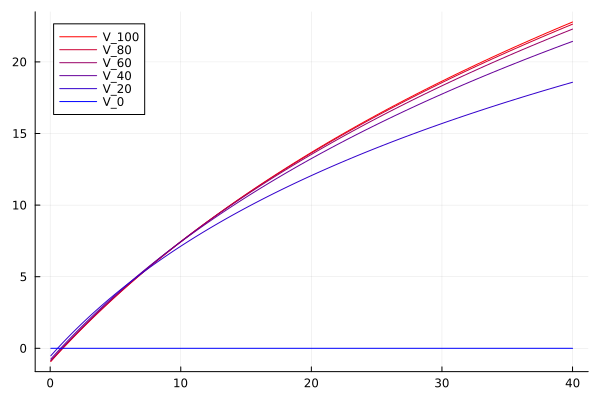

In [5]:
b_grid = loggrid(0.05, 40.0, 400)
params = (;β=0.96, R=1.04, z=1.0, b_grid)

# Guess initial V
V = zeros(size(b_grid))
V_iterations = [copy(V)]

for chunk=1:5
     for i = 1:20
        V = bellman_operator(V, params)
    end
    push!(V_iterations, copy(V))
end

plot(b_grid, hcat(reverse(V_iterations)...); label=["V_100" "V_80" "V_60" "V_40" "V_20" "V_0"], palette=palette([:red, :blue], length(V_iterations)))

### Policy Function

The policy function is the same operator as the Bellman operator, with
`argmax` in place of `max`:
$$
c^\star(b) \;=\; \arg\max_{c \in [0, b]} \; u(c) + \beta\, V\!\big(R(b - c) + z\big).
$$

In [6]:
"""
    Compute the policy index vector `c_ind` from V.
    For each row of b_grid, returns the column index in b_grid of the optimal next-period wealth b'.
"""
function policy_function(V, params)
    (; β, R, z, b_grid) = params

    # same setup as bellman_operator
    b_end = (b_grid' .- z) ./ R

    # argmax over b' (columns) — pull out the column index for each row
    idx = argmax(u.(b_grid .- b_end) .+ β .* V'; dims=2)
    return vec(getindex.(idx, 2))::Vector{Int}
end


policy_function

# Run the code

In [7]:
# Construct household params
b_grid = loggrid(0.05, 40.0, 400)
params = (;β=0.96, R=1.04, z=1.0, b_grid)

# Solve for V by VFI
V = solve_vfi(params)

# read the policy off the converged V
# c_ind[i] is the chosen b'-index at b_grid[i]
c_ind = policy_function(V, params)

400-element Vector{Int64}:
   1
   1
   1
   2
   2
   3
   3
   4
   5
   6
   ⋮
 392
 393
 394
 395
 396
 397
 398
 399
 400